In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Prediction vs Inference

## Two approaches to the same data

In this notebook, we are going to model likelihood of surviving the Titanic disaster. We will do with two objectives in mind: **Prediction** and **Inference**. Use this notebook as inspiration (but *not* as a template) for your own project sections. You should not be viewing the methods applied as a checklist, but as indications of how to think about each objective.

- For Prediction, we want to predict survival as best we can.

- For Inference, we want to evaluate whether Age influenced the likelihood of survival.

In [2]:
# Read in the training data and do some light data cleaning
titanic_train = pd.read_csv("./data/train.csv")
titanic_train.drop(["PassengerId","Name","Ticket","Cabin","Embarked"], axis = 1, inplace = True)
titanic_train.dropna(inplace = True)
titanic_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [3]:
# Check sample size
len(titanic_train)

714

In [4]:
# More data cleaning and define predictos and target
X = titanic_train.drop("Survived", axis = 1)
X.loc[:,"Sex"] = X["Sex"].replace(["female","male"], [0,1])
y = titanic_train["Survived"]

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_73174/3567592045.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.loc[:,"Sex"] = X["Sex"].replace(["female","male"], [0,1])


0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

## Prediction

Our objective in this section is prediction: we want to choose a target in the data and try to model it as well as we can.

Our target is "survived", where a 1 indicates the passenger survived and 0 that they didn't. This is a binomial, categorical variables that we'd like to correctly assign a class to i.e. a classification problem.

When thinking of which classifier to use, it helps to think about the shape of the decision boundaries between our data and the target. Classes that are highly separated along our predictors tend to be modeled well with **linear or quadratic decision boundaries** (e.g. logistic regression, linear or quadratic discriminant analysis). 

The less linear the separation, the **more flexible** we want our decision boundaries to be to track that complexity.

Start by looking at the overall associations with survival:

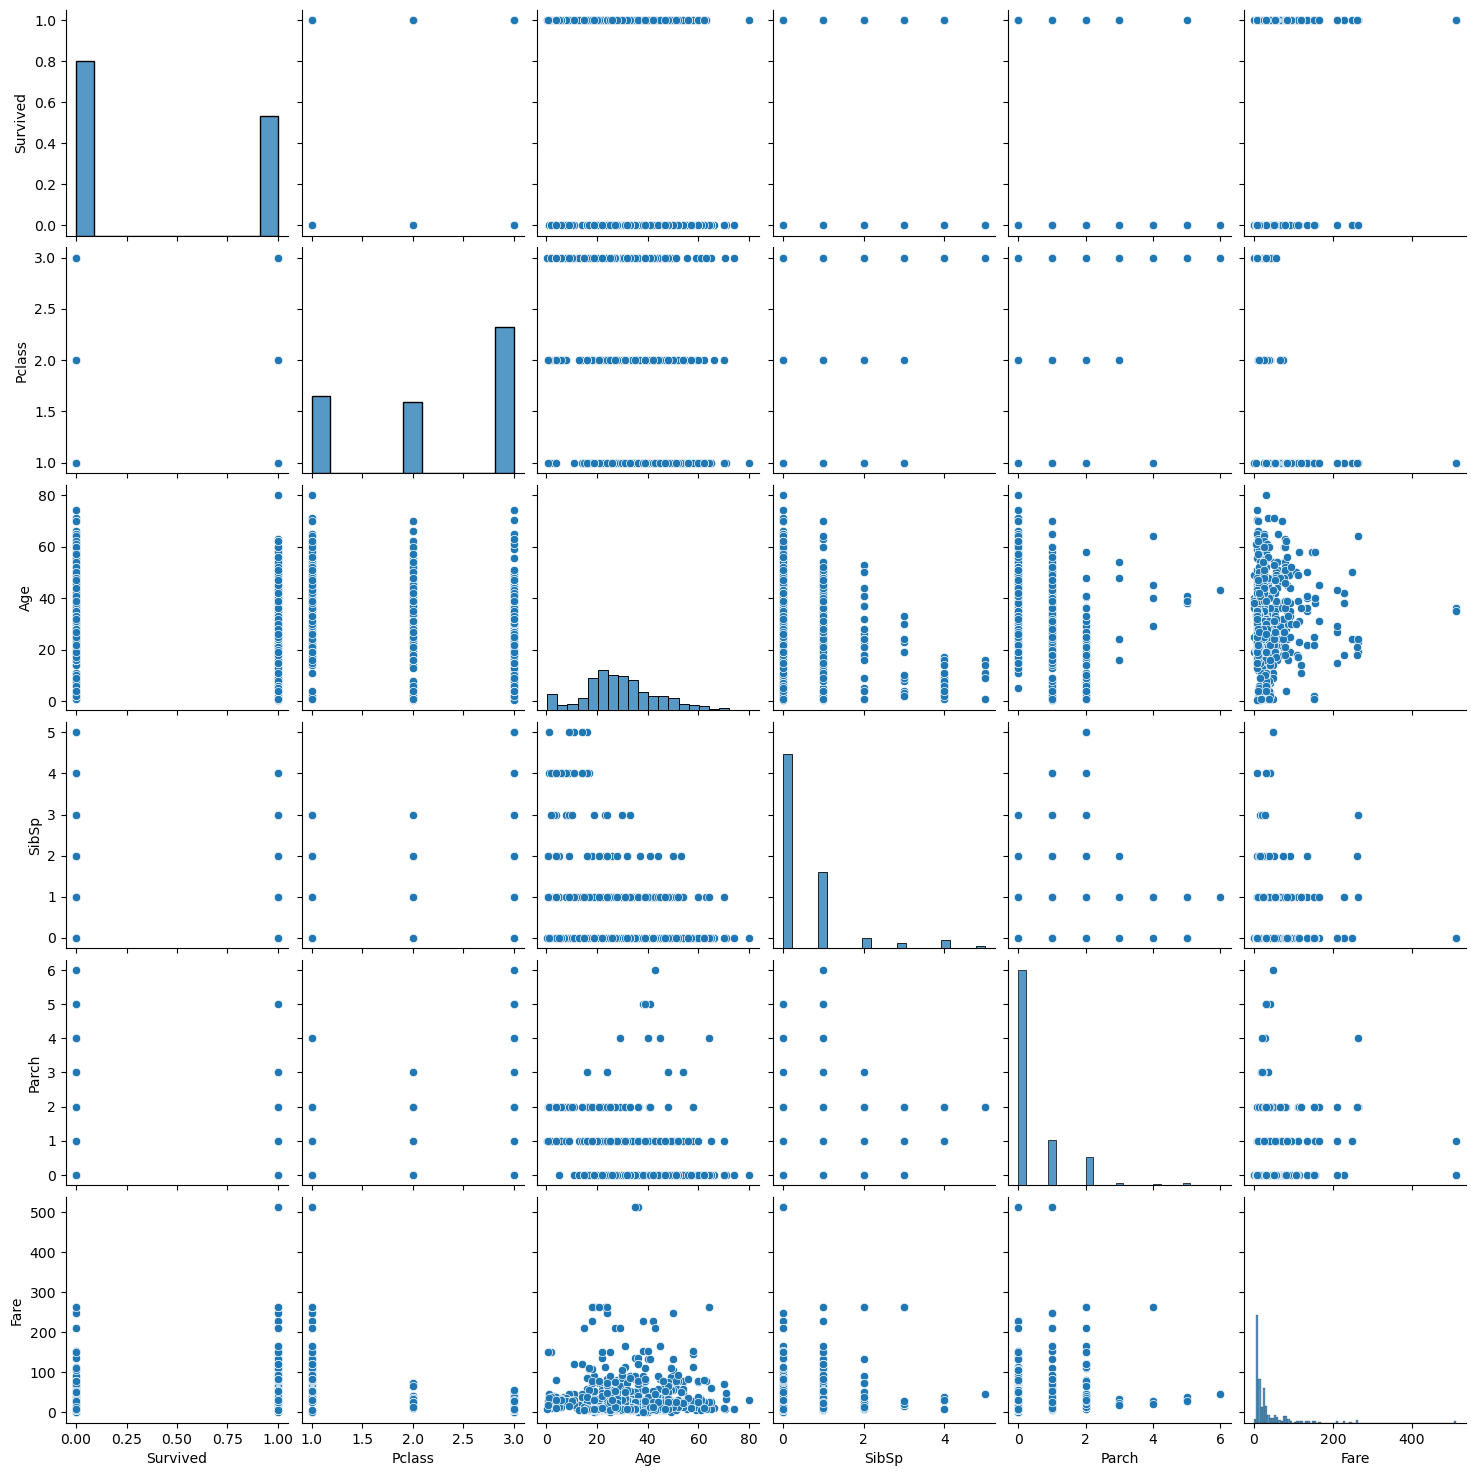

In [5]:
sns.pairplot(titanic_train)

<Axes: xlabel='Age', ylabel='Fare'>

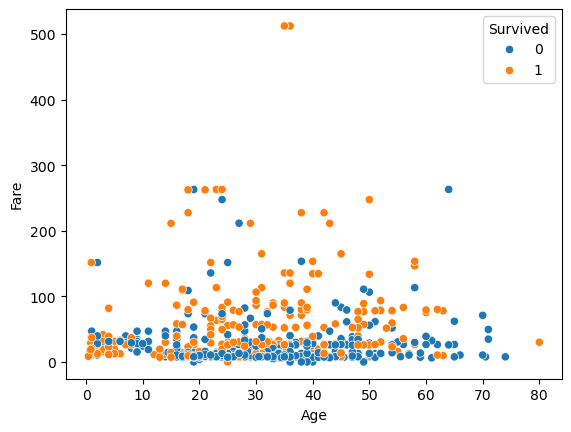

In [6]:
# Plot the association of Age and Fare, changing color by survival
sns.scatterplot(x = X["Age"], y = X["Fare"], hue = y)

Could you easily seperate these classes in a linear fashion?

<Axes: xlabel='Pclass', ylabel='SibSp'>

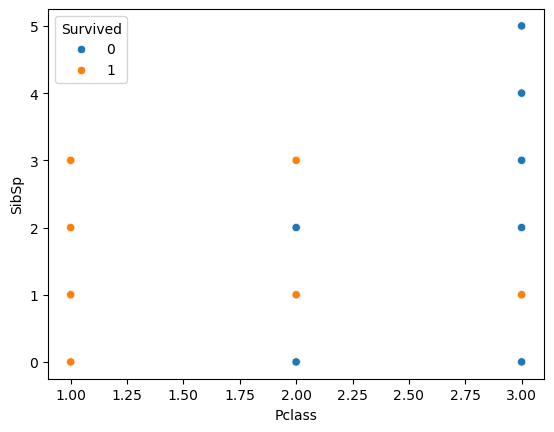

In [7]:
# Plot the association of Class and number Children, changing color by survival
sns.scatterplot(x = X["Pclass"], y = X["SibSp"], hue = y)

Too much overplotting, so let's add some noise.

<Axes: xlabel='Pclass', ylabel='SibSp'>

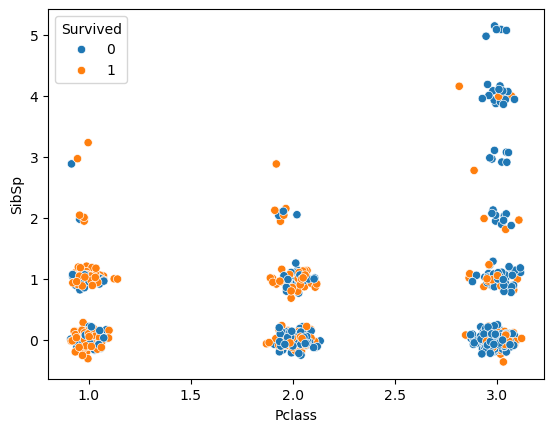

In [8]:
# Create random, normally distributed variables for noise with magnitude proportional to scale of variable
x_jitter = np.random.normal(0, .05, size=len(X))
y_jitter = np.random.normal(0, .1, size=len(X))

sns.scatterplot(x = X["Pclass"] + x_jitter, y = X["SibSp"] + y_jitter, hue = y)

Could you easily seperate these classes in a linear fashion?

### Logistic Regression

We might be skeptical that Logistic Regression (which produces  linear decision boundaries) will do well on these data, but let's try anyway for the purpose of trying out different classifiers and model comparison.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Instantiate a Logistic Regression model with no regularization penalty
lrm = LogisticRegression(penalty = None)

# Fit model and predict off of X
lrm_fit = lrm.fit(X, y)
y_preds = lrm_fit.predict(X)

# Find log loss of the predictions
log_loss(y_preds, y)

7.0673830174739525

In [10]:
# And find accuracy
accuracy = np.sum(y_preds == y)/len(y)
accuracy

0.803921568627451

We should make sure our classes are relatively balanced to be ensure accuracy is a reasonable metric.

In [11]:
pd.value_counts(y)

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_48577/3605348509.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(y)


Survived
0    424
1    290
Name: count, dtype: int64

In [12]:
424/(424 + 290)

0.5938375350140056

Now look at the coefficients associated with each predictor to see their influence on survival.

In [14]:
log_mult_reg = pd.DataFrame({"pred": X.columns, "coefficient":lrm_fit.coef_[0]})
log_mult_reg

,pred,coefficient
0,Pclass,-1.242335
1,Sex,-2.634911
2,Age,-0.043957
3,SibSp,-0.375669
4,Parch,-0.061923
5,Fare,0.002159


Rather than look just at accuracy, we could be a little more sophisticated and use e.g. a ROC curve.

In [15]:
# Predict probabilities of 1 for each x
y_preds_probs = lrm_fit.predict_proba(X)
y_preds_probs[:,1][0:10]

array([0.09115582, 0.90507216, 0.63102257, 0.91273653, 0.07630473,
       0.3209129 , 0.09940246, 0.59284241, 0.87852776, 0.74744068])

Text(0, 0.5, 'True Positive Rate')

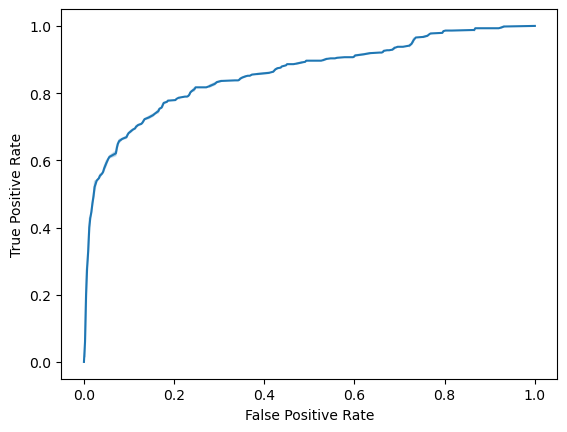

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Derive false positive, true positive rates
fpr, tpr, thresholds = roc_curve(y, y_preds_probs[:,1])

sns.lineplot(x = fpr, y = tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

In [18]:
#Find the area under curve (AUC)
roc_auc_score(y, y_preds_probs[:,1])

0.8590761223162005

ROC Curves and AUC are more nuanced ways of comparing classifiers compared with accuracy or log loss. As we know, Whether we care about overall loss, false positives, or false negatives more depends on our specific modeling problem.

This would be a good time to go further and do some best subset selection, but we'll keep going for now.

*insert K-fold cross-validation for best subset selection*

### Random Forest

Our Logistic Regression model is totally reasonable (~80% accuracy with balanced classes is ok!). But our visual evaluation of class separability does suggest a more flexible model would be better. Random forests are examples of flexible classifiers, as are KNN and NN. Let's try an RFC.

In [19]:
from sklearn.ensemble import RandomForestClassifier

#Instantiate classifier
rfc = RandomForestClassifier()

# Fit the RFC to X and y and find log loss
rfc_fit = rfc.fit(X, y)
y_preds = rfc_fit.predict(X)
log_loss(y, y_preds)

0.5048130726767109

This is a much lower log loss on the full data! 

In [20]:
accuracy = np.sum(y_preds == y)/len(y)
accuracy

0.9859943977591037

And accuracy. We don't need to do cross-validation to determine that a random forest classifier is better than logistic regression for this problem, thought it would be strictly best practice to calculate a CV score for the two models and see which is better.

Now that we've established that random forests are a better modeling framework for predicting survival, we want to find the best version of our classifier. In all modeling contexts (and for tree-based methods in particular), it is important to control for the risk of overfitting by limiting the number of branches in our decision trees (pruning). We'll use hyperparameter selection for max tree depth with k-fold cross-validation.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# Create train test splits
X_train, X_holdout, Y_train, Y_holdout = train_test_split(X, y, test_size = 0.2)

# Create an array of max tree depths
max_depths = np.arange(1,30)

# Get ready to split the training data into 5 folds
kf = KFold(n_splits = 5)

# Empty object for appending cv scores for each depth
depth_errors = np.empty(0)

# For each depth
for i in max_depths:

    # Instantiate RFC with max depth i
    rfc = RandomForestClassifier(max_depth = i)
    
    validation_errors = np.empty(0)

    # For each split in the training data
    for train_idx, valid_idx in kf.split(X_train):

        # Create training and validation Xs and ys
        split_X_train, split_X_valid = X_train.iloc[train_idx,:], X_train.iloc[valid_idx,:]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx] 

        # Fit on training splits
        rfc.fit(split_X_train, split_Y_train)

        # Predict on validation split
        Y_pred = rfc.predict(split_X_valid)

        # Save the log loss of the split
        validation_errors = np.append(validation_errors, log_loss(split_Y_valid, Y_pred))

    # Save the mean validation error (the cross-validation score) for the current depth
    depth_errors = np.append(depth_errors, np.mean(validation_errors))

In [23]:
# Return depths in order of best CV score
depth_and_loss = pd.DataFrame({"depth": max_depths, "log loss": depth_errors})
depth_and_loss.sort_values("log loss", ascending = True).head()

,depth,log loss
6,7,5.872009
7,8,6.186532
8,9,6.376785
5,6,6.566488
4,5,6.692957


Text(0, 0.5, 'CV Score')

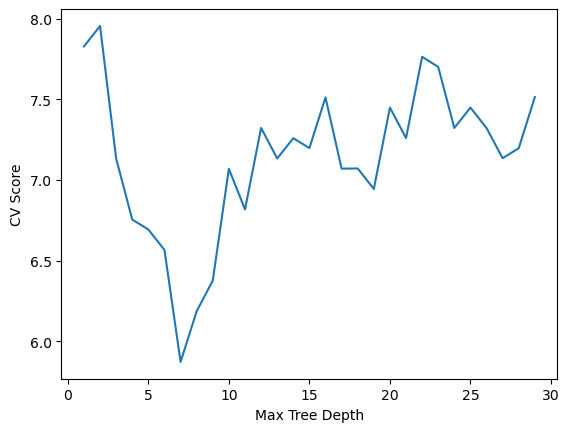

In [25]:
# Plot CV score by max tree depth
sns.lineplot(data = depth_and_loss, x = "depth", y = "log loss")
plt.xlabel("Max Tree Depth")
plt.ylabel("CV Score")

We now know a range of max depths that neither underfits or overfits our data using random forests. Now bring in the test data for final evaluation.

In [26]:
titanic_test = pd.read_csv("./data/test.csv")
titanic_test.drop(["PassengerId","Name","Ticket","Cabin","Embarked"], axis = 1, inplace = True)
titanic_test.dropna(inplace = True)

In [27]:
titanic_test = pd.read_csv("./data/test.csv")
titanic_test.drop(["PassengerId","Name","Ticket","Cabin","Embarked"], axis = 1, inplace = True)
titanic_test.dropna(inplace = True)

X_test = titanic_test.drop("Survived", axis = 1)
X_test.loc[:,"Sex"] = X_test["Sex"].replace(["female","male"], [0,1])
y_test = titanic_test["Survived"]

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_48577/2228011438.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.loc[:,"Sex"] = X_test["Sex"].replace(["female","male"], [0,1])


Check final test loss with the best model derived from above.

In [28]:
rfc = RandomForestClassifier(max_depth = 7)
rfc_fit = rfc.fit(X, y)
y_preds = rfc_fit.predict(X_test)
log_loss(y_test, y_preds)

4.355728506237722

In [29]:
accuracy = np.sum(y_preds == y_test)/len(y_test)
accuracy

0.879154078549849

Compare to loss we would have had without  model selection and hyperparameter tuning.

In [30]:
rfc = RandomForestClassifier()

rfc_fit = rfc.fit(X, y)
y_preds = rfc_fit.predict(X_test)
log_loss(y_test, y_preds)

6.751379184668469

In [31]:
accuracy = np.sum(y_preds == y_test)/len(y_test)
accuracy

0.8126888217522659

### Summary

Our target did not seem to have great linear separation in variable space, explaining why the random forest classifier (which is much more flexible) performed better on it than our logistic regression model. We further fine-tuned our classifier by using k-fold cross validation to select a version of the model that was less likely to overfit the test data.

But unlike random forests, logistic regression is parametric. We can use the values of the coefficients associated with certain predictors to learn about what influenced survival of passengers on the Titanic i.e. do Inference.

## Inference

We're switching objectives now. Before, we were just predicting survival to the best of our ability. Now we want to answer a specific question:

**Did age affect the likelihood of surviving the Titanic?**

***Hypothesis***: The older you are, the more likely you are to survive!

***Null hypothesis***: Age has no effect on the probability of survival

I'm more interested in the question than the specific hypothesis, but I'm just assigning a directionality to the hypothesis because maybe being older afforded you certain privileges when getting off the boat.

Before we were only working with a training split of the data. *We don't really care about generalization error for Inference*. What we care about is using all of the data at our disposal to develop our highest confidence estimate of Age on Survival. 

In [32]:
titanic = pd.concat([titanic_train, titanic_test])
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [33]:
len(titanic)

1045

Let's visualize the association.

<Axes: xlabel='Age', ylabel='Survived'>

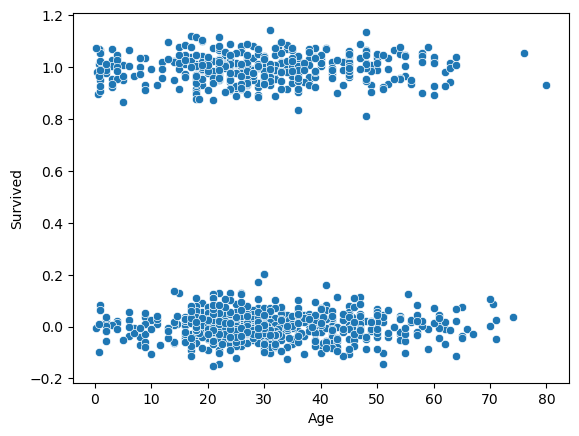

In [34]:
y_jitter = np.random.normal(0, 0.05, size = len(titanic))
sns.scatterplot(x = titanic["Age"], y = titanic["Survived"] + y_jitter)

Now split data into predictors and target. Since we're trying to learn the effect of one predictor (age), we will use just that in our logistic regression model.

In [35]:
X = titanic.drop("Survived", axis = 1)
X.loc[:,"Sex"] = X["Sex"].replace(["female","male"], [0,1])

y = titanic["Survived"]

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_48577/4056099528.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.loc[:,"Sex"] = X["Sex"].replace(["female","male"], [0,1])


In [36]:
lrm = LogisticRegression(fit_intercept = True)
lrm_fit = lrm.fit(X[["Age"]], y)

In [37]:
lrm_fit.coef_

array([[-0.00746086]])

In [38]:
lrm_fit.intercept_

array([-0.18792896])

We know that this is the model of best fit. Let's visualize it over the data. We'll include a dashed line to represent our null hypothesis.

In [39]:
# Create x values to predict across and reshape to be columnar
xs = np.arange(0,80,0.5).reshape(-1,1)

# Predict the probabilities of surivival of each x, choosing the second column of values which correspond to p = 1
preds = lrm_fit.predict_proba(xs)[:,1]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


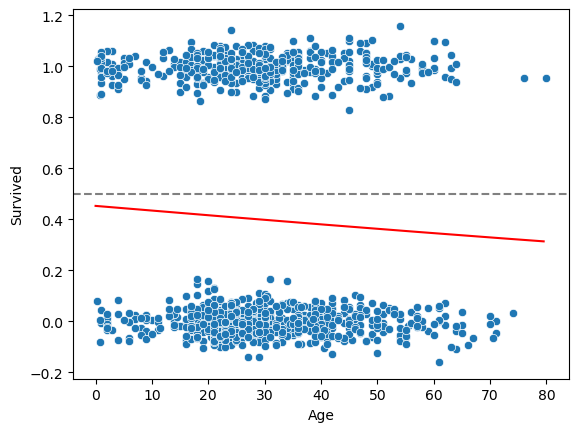

In [40]:
# Noise for the y axis
y_jitter = np.random.normal(0, 0.05, size = len(titanic))

# Plot with the predictions and null hypothesis line
sns.scatterplot(x = titanic["Age"], y = titanic["Survived"] + y_jitter)
plt.plot(xs, preds, c = "red")
plt.axhline(y = 0.5, c = "gray", linestyle = "dashed")

Our coefficient was negative, and our prediction surface indeed suggests that likelihood of survival decreases with age. This is the opposite of our hypothesis - that you were less likely to survive the older you were!

But this is Inference and our job is not done. We still need to evaluate our confidence in the observed effect, and consider assumptions. In other words, just how likely is it that the red line differs from the gray line by chance?

If we were in 102, we'd bootstrap the model and develop a confidence interval around our "slope". Because we already conceptually understand this, we'll just use `statsmodels` to tell us the confidence.

In [41]:
import statsmodels.api as sm

# Add a bias to the X design matrix
X_sm = sm.add_constant(X[["Age"]])

# Fit a logistic model and return summary
log_reg = sm.Logit(y, X_sm).fit()
log_reg.summary()

Optimization terminated successfully.
         Current function value: 0.671255
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                 1045
Model:                          Logit   Df Residuals:                     1043
Method:                           MLE   Df Model:                            1
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                0.002032
Time:                        20:58:13   Log-Likelihood:                -701.46
converged:                       True   LL-Null:                       -702.89
Covariance Type:            nonrobust   LLR p-value:                   0.09101
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1879      0.145     -1.293      0.196      -0.473       0.097
Age           -0.0075      0.004     -1.684      0.092      -0.016       0.001
==============================================================================
"""

We have a low p-value, though it is not at the .05 threshold we often treat as some gold standard. How should we think about our confidence in this case? Let's consider some factors.

(1) **Does the observed effect make sense?** Yes. Harder to get on a lifeboat? Less likely to survive in the water? Women and children first? 

- The fact that there are plausible explanations for the effect pushes us toward believing it

(2) **Does the effect matter?**

In [42]:
### Backtransform the log odds ratio to create an odds ratio
Age_coef = np.exp(-.0075)
Age_coef

0.9925280548191384

This means that for every 1 unit increase in age, your odds of survival are multiplied by 0.993, or equivalenty are decreased by .07%. This is a very small effect size and pushes us away from believing it.

(3) **Is Age associated with other causal factors that could mediate the association or lack thereof?** Would be a good idea to explore in the data.

Explore the multiple regression coefficients:

In [43]:
log_mult_reg

,pred,coefficient
0,Pclass,-1.242335
1,Sex,-2.634911
2,Age,-0.043957
3,SibSp,-0.375669
4,Parch,-0.061923
5,Fare,0.002159


The coefficient is different in the multiple regression (`-.044` instead of `-.0075`). This is interesting and suggests two things:

- That age is correlated with one or more of the other predictors i.e they are covariates
- That noise introduced from one of the covariates could be suppressing the influence of age in the simple linear model. Controlling for the noise introduced by the supressing variable reveals a larger effect of Age. This is called a suppression effect.

We could go further down this rabbithole, trying to identify the relevant covariate and evaluating whether it is in fact supressing Age on Survival. We won't in this notebook.

We should evaluate other ways in which the direct association could be mediated by other factors not in the data. In other words, what parts of the story are our data not capturing?

- Maybe people with more children were more likely to get on the boat (**+ effect of age**), but children were more likely to get on the boat (**- effect of age**), which could cancel out any statistically distinguishable effect even though age is influencing survival in meaningful ways.
- More thoughts...

The point is that Inference is tricky and requires a lot of thinking beyond just your statistics and code! 

**So what then is our conclusion for this objective?**

**Conclusion** ...

## Wrapping up

This notebook hopefully gives you a clearer sense of how we go about doing Prediction vs Inference with the same data.

**Prediction**:
- Choose a modeling framework flexible enough to model survival as a function of its predictors
- Do model comparison with cross-validation to find the best version of your considered models.
- Perform final model evaluation against the test set and quantify/visualize loss metrics

**Inference**:
- Develop some question or hypothesis answerable with your data
- Choose a modeling framework interpretable enough to let you evaluate a hypothesis using the observed statistics
- Evaluate statistical confidence in the resulting observed statistics
- Consider all of the ways both present in your data and not present in your data that could challenge any straightforward conclusions that you draw from your observed effects
- Make a conclusion about your initial question or hypothesis